In [1]:
import torch

seed = 2024

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(seed=seed)
torch.set_float32_matmul_precision("high")

if device.type == "cuda" :
    torch.cuda.manual_seed_all(seed=seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_dataset = datasets.MNIST(
    root = "./mnist/",
    train = True,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(64),
        transforms.Normalize(0.5, 0.5),
    ]),
    download = True
)

test_dataset = datasets.MNIST(
    root = "./mnist/",
    train = False,
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(64),
        transforms.Normalize(0.5, 0.5),
    ]),
    download = True
)


In [5]:
import torch
from torchvision import utils
import matplotlib
from matplotlib import pyplot as plt
import numpy as np

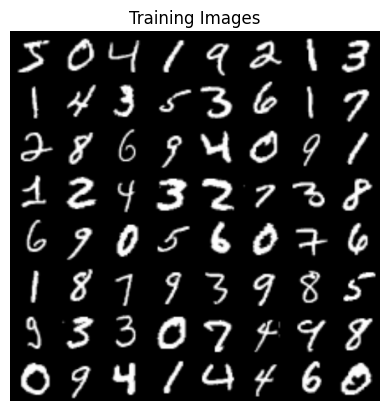

In [6]:
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(utils.make_grid(torch.cat([train_dataset[i][0].unsqueeze(0) for i in range(64)], dim=0), normalize=True), (1,2,0)))

## DCGAN (Deep Convolutional Generative Adversarial Network)

In [7]:
from torch import nn

In [18]:
class Generator(nn.Module):
    def __init__(self,
                 latent_dim: int=64,
                 base_channels: int=64,
                 out_channels: int=1):
        super().__init__()
        
        self.model = nn.Sequential(
            # input : latent_dim * 1 * 1
            nn.ConvTranspose2d(latent_dim, base_channels*8, kernel_size=4, stride=1, bias=False),
            nn.BatchNorm2d(base_channels*8),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(base_channels*8, base_channels*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels*4),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(base_channels*4, base_channels*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels*2),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(base_channels*2, base_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(base_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),   
        )
    
    def forward(self, z):
        return self.model(z)

In [9]:
class Discriminator(nn.Module):
    def __init__(self,
                 in_channels: int=1,
                 base_channels : int=64):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(base_channels, base_channels*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels*2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(base_channels*2, base_channels*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels*4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(base_channels*4, base_channels*8, 4, 2,1, bias=False),
            nn.BatchNorm2d(base_channels*8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(base_channels*8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.model(x)

In [10]:
def weights_init(module) :
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.normal_(module.weight.data, 0.0, 0.02) # 가중치를 mean=0, std=0.02인 정규분포에서 초기화

In [11]:
import os

In [13]:
os.makedirs("results", exist_ok=True)

In [14]:
base_channels = 64
batch_size = 128
num_epochs = 20
latent_dim = 32

lr = 0.0002
lr_adv = 0.0002
beta1 = 0.5

In [15]:
train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    shuffle = True,
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [16]:
from torch import optim

In [20]:
generator = Generator(latent_dim, out_channels=1, base_channels=base_channels).to(device)
discriminator = Discriminator(in_channels=1, base_channels = base_channels).to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [21]:
optim_g = optim.Adam(generator.parameters(), lr, betas=(beta1, 0.999))
optim_d = optim.Adam(discriminator.parameters(), lr_adv, betas=(beta1, 0.999))

In [22]:
criterion = nn.BCELoss()

In [23]:
train_loss_g_epoch, train_loss_d_epoch = [], []
val_loss_g_epoch, val_loss_d_epoch = [], []

In [24]:
fixed_z = torch.randn((64, latent_dim, 1, 1), device = device)

In [ ]:
for epoch in range(1, num_epochs+1) :
    total_loss_g, total_loss_d = 0.0, 0.0
    total_num_data = 0
    
    generator.train()
    discriminator.train()
    
    for i, data in enumerate(train_loader):
        real_data = data[0].to(device)
        num_data = real_data.size(0)
        total_num_data += num_data
        